In [ ]:
from pathlib import Path
import json
import urllib.request
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _trebl_notebook_stem():
    try:
        import ipykernel

        connection_file = Path(ipykernel.get_connection_file()).name
        kernel_id = connection_file.split('-', 1)[1].split('.', 1)[0]

        try:
            from notebook import notebookapp

            servers = list(notebookapp.list_running_servers())
        except Exception:
            from jupyter_server import serverapp

            servers = list(serverapp.list_running_servers())

        for srv in servers:
            token = srv.get('token', '')
            api_url = f"{srv['url'].rstrip('/')}/api/sessions"
            if token:
                api_url = f"{api_url}?token={token}"

            with urllib.request.urlopen(api_url, timeout=2) as response:
                sessions = json.loads(response.read().decode('utf-8'))

            for sess in sessions:
                if sess.get('kernel', {}).get('id') == kernel_id:
                    notebook_path = sess.get('notebook', {}).get('path') or sess.get('path', '')
                    raw_stem = Path(notebook_path).stem or 'notebook'
                    safe_stem = ''.join(ch if (ch.isalnum() or ch in {'_', '-'}) else '_' for ch in raw_stem)
                    return safe_stem.strip('_') or 'notebook'
    except Exception:
        pass

    return 'notebook'


if not hasattr(plt, '_trebl_autosave_original_show'):
    plt._trebl_autosave_original_show = plt.show
    plt._trebl_autosave_counter = 1
    plt._trebl_notebook_stem = _trebl_notebook_stem()

    def _trebl_autosave_show(*args, **kwargs):
        for fig_num in plt.get_fignums():
            fig = plt.figure(fig_num)
            stem = f"{plt._trebl_notebook_stem}_figure_{plt._trebl_autosave_counter:04d}"
            fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
            fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
            plt._trebl_autosave_counter += 1
        return plt._trebl_autosave_original_show(*args, **kwargs)

    plt.show = _trebl_autosave_show


In [5]:
import pandas as pd
import numpy as np
import glob as glob
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
import re
import duckdb
# from joblib import Parallel, delayed

# RT UMI counts

In [3]:
chunk_umi_count_paths = glob.glob("../../../output/ChopTFs_pipeline/downsampling/*RP*/*reads_per_umi.tsv")
len(chunk_umi_count_paths)

92

In [12]:
con = duckdb.connect(database=":memory:")

results = []

for path in tqdm(chunk_umi_count_paths):
    try:
        n = con.execute(
            """
            SELECT COUNT(DISTINCT UMI)
            FROM read_csv(
                ?,
                delim='\t',
                header=true,
                auto_detect=false,
                columns={
                    'RPTR_BC': 'VARCHAR',
                    'UMI': 'VARCHAR',
                    'reads': 'INTEGER'
                }
            )
            """,
            [path],
        ).fetchone()[0]

        results.append({"path": path, "unique_umis": n})

    except Exception as e:
        results.append({"path": path, "unique_umis": None, "error": str(e)})

df = pd.DataFrame(results)
df

100%|██████████| 92/92 [00:04<00:00, 22.39it/s]


,path,unique_umis
0,../../../output/ChopTFs_pipeline/downsampling/...,71380
1,../../../output/ChopTFs_pipeline/downsampling/...,57718
2,../../../output/ChopTFs_pipeline/downsampling/...,425294
3,../../../output/ChopTFs_pipeline/downsampling/...,425104
4,../../../output/ChopTFs_pipeline/downsampling/...,780334
...,...,...
87,../../../output/ChopTFs_pipeline/downsampling/...,524818
88,../../../output/ChopTFs_pipeline/downsampling/...,222328
89,../../../output/ChopTFs_pipeline/downsampling/...,2741994
90,../../../output/ChopTFs_pipeline/downsampling/...,71074


In [13]:
df['num_splits'] = df['path'].str.extract(r'_(\d+)_chunks').astype(int)
df

,path,unique_umis,num_splits
0,../../../output/ChopTFs_pipeline/downsampling/...,71380,64
1,../../../output/ChopTFs_pipeline/downsampling/...,57718,512
2,../../../output/ChopTFs_pipeline/downsampling/...,425294,64
3,../../../output/ChopTFs_pipeline/downsampling/...,425104,64
4,../../../output/ChopTFs_pipeline/downsampling/...,780334,32
...,...,...,...
87,../../../output/ChopTFs_pipeline/downsampling/...,524818,2
88,../../../output/ChopTFs_pipeline/downsampling/...,222328,128
89,../../../output/ChopTFs_pipeline/downsampling/...,2741994,4
90,../../../output/ChopTFs_pipeline/downsampling/...,71074,64


In [14]:
df["path"].iloc[0]

'../../../output/ChopTFs_pipeline/downsampling/trebl_experiment_RP_2_2_S32_R1_001_fastp_64_chunks_part_1_fq_gz/RP_2_2_S32_R1_001_fastp_64_chunks_part_1.fq_reads_per_umi.tsv'

In [16]:
df["percent_reads"] = 100 / df["num_splits"]
df["time"] = df["path"].str.extract("RP_2_(\d+)_")
df

,path,unique_umis,num_splits,percent_reads,time
0,../../../output/ChopTFs_pipeline/downsampling/...,71380,64,1.562500,2
1,../../../output/ChopTFs_pipeline/downsampling/...,57718,512,0.195312,40
2,../../../output/ChopTFs_pipeline/downsampling/...,425294,64,1.562500,40
3,../../../output/ChopTFs_pipeline/downsampling/...,425104,64,1.562500,40
4,../../../output/ChopTFs_pipeline/downsampling/...,780334,32,3.125000,40
...,...,...,...,...,...
87,../../../output/ChopTFs_pipeline/downsampling/...,524818,2,50.000000,2
88,../../../output/ChopTFs_pipeline/downsampling/...,222328,128,0.781250,40
89,../../../output/ChopTFs_pipeline/downsampling/...,2741994,4,25.000000,40
90,../../../output/ChopTFs_pipeline/downsampling/...,71074,64,1.562500,2


In [17]:
df["time"].value_counts()

time
2     31
40    31
10    30
Name: count, dtype: int64

In [18]:
df = df.drop(columns = 'path')
df

,unique_umis,num_splits,percent_reads,time
0,71380,64,1.562500,2
1,57718,512,0.195312,40
2,425294,64,1.562500,40
3,425104,64,1.562500,40
4,780334,32,3.125000,40
...,...,...,...,...
87,524818,2,50.000000,2
88,222328,128,0.781250,40
89,2741994,4,25.000000,40
90,71074,64,1.562500,2


In [20]:
time_2_summary = df[df["time"] == "2"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()
time_2_summary["percent_reads"] = time_2_summary["percent_reads"].astype(int)
time_2_summary

/tmp/ipykernel_1590792/3492397091.py:1: FutureWarning: The provided callable <function mean at 0x153ed31a4400> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  time_2_summary = df[df["time"] == "2"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()
/tmp/ipykernel_1590792/3492397091.py:1: FutureWarning: The provided callable <function std at 0x153ed31a4540> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  time_2_summary = df[df["time"] == "2"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()


num_splits percent_reads time unique_umis            
                                       mean         std
0          2            50    2   524847.50   41.719300
1          4            25    2   453652.75  180.786015
2          8            12    2   343520.60  297.930864
3         32             3    2   131023.00  219.053646
4         64             1    2    71202.80  145.364026
5        128             0    2    37242.20   62.547582
6        512             0    2     9628.00   43.451122

In [21]:
time_10_summary = df[df["time"] == "10"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()
time_10_summary["percent_reads"] = time_10_summary["percent_reads"].astype(int)
time_10_summary

/tmp/ipykernel_1590792/3979189018.py:1: FutureWarning: The provided callable <function mean at 0x153ed31a4400> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  time_10_summary = df[df["time"] == "10"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()
/tmp/ipykernel_1590792/3979189018.py:1: FutureWarning: The provided callable <function std at 0x153ed31a4540> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  time_10_summary = df[df["time"] == "10"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()


num_splits percent_reads time unique_umis            
                                       mean         std
0          2            50   10  1218289.50  593.262589
1          4            25   10  1051992.75  741.290035
2          8            12   10   800052.80  653.540129
3         32             3   10   309284.80  236.295789
4         64             1   10   168867.40  289.489723
5        128             0   10    88408.00  203.724078
6        512             0   10    22935.50   26.006409

In [22]:
time_40_summary = df[df["time"] == "40"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()
time_40_summary["percent_reads"] = time_40_summary["percent_reads"].astype(int)
time_40_summary

/tmp/ipykernel_1590792/1443195289.py:1: FutureWarning: The provided callable <function mean at 0x153ed31a4400> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  time_40_summary = df[df["time"] == "40"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()
/tmp/ipykernel_1590792/1443195289.py:1: FutureWarning: The provided callable <function std at 0x153ed31a4540> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  time_40_summary = df[df["time"] == "40"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()


num_splits percent_reads time unique_umis            
                                       mean         std
0          2            50   40   3210291.5  622.961074
1          4            25   40   2742189.0  527.126803
2          8            12   40   2052546.6  866.080424
3         32             3   40    780627.8  387.185614
4         64             1   40    425192.6   91.647695
5        128             0   40    222552.6  173.047103
6        512             0   40     57727.4   76.461101

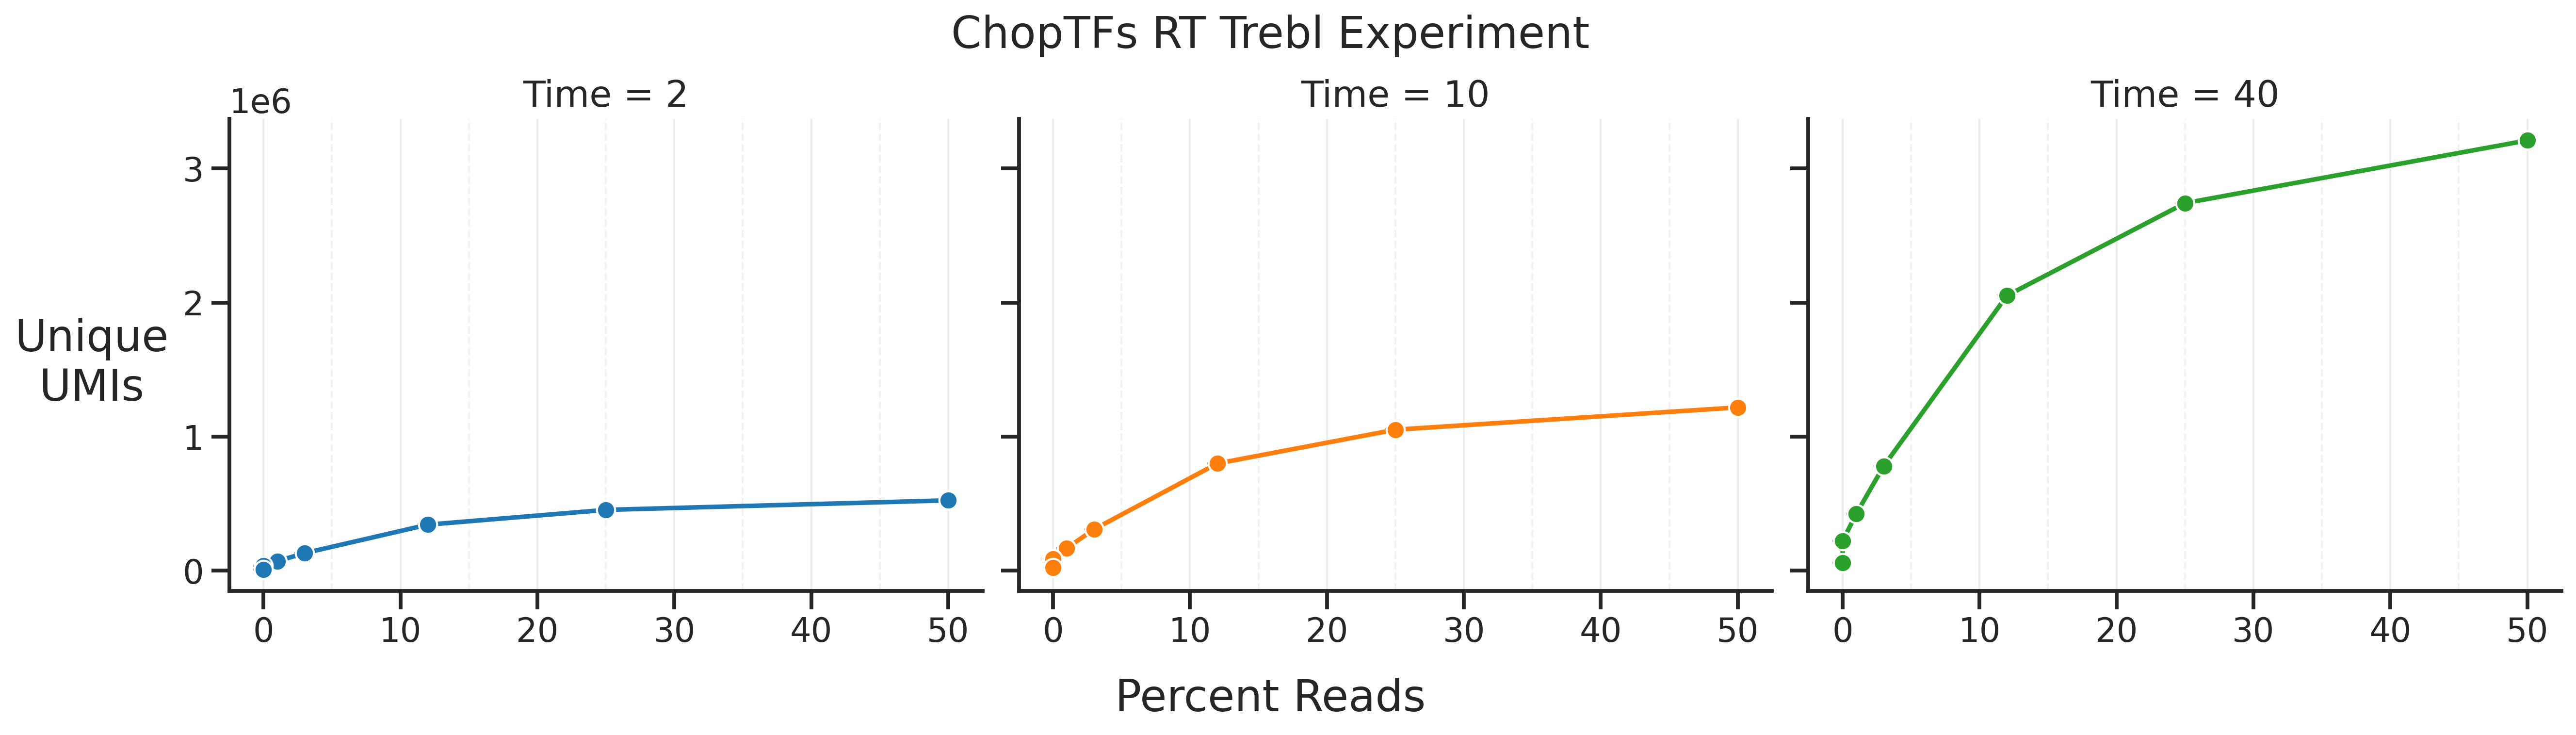

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns

sns.set_style("ticks")
sns.set_context("talk")

fig, axes = plt.subplots(
    1, 3, figsize=(18, 5), dpi=300, sharex=True, sharey=True
)

# Dictionary of summaries and colors
time_summaries = {
    'Time = 2': (time_2_summary, '#1f77b4'),   # blue
    'Time = 10': (time_10_summary, '#ff7f0e'), # orange
    'Time = 40': (time_40_summary, '#2ca02c'), # green
}

# Plot each time point
all_x = []
all_y = []

for ax, (title, (summary, color)) in zip(axes, time_summaries.items()):
    x = summary['percent_reads']
    y_mean = summary[('unique_umis', 'mean')]
    y_std = summary[('unique_umis', 'std')]
    
    all_x.append(x)
    all_y.append(y_mean)
    
    ax.errorbar(
        x=x,
        y=y_mean,
        yerr=y_std,
        fmt='-o',
        capsize=5,
        color=color,
        ecolor='tab:gray',
        elinewidth=2,
        markeredgecolor='white'
    )
    ax.set_title(title)
    ax.set_xlabel("")
    sns.despine(ax=ax)

# Shared limits and grids
all_x_concat = np.concatenate(all_x)
x_min, x_max = all_x_concat.min(), all_x_concat.max()
y_max = max(y.max() for y in all_y) * 1.05

for ax in axes:
    #ax.set_xlim(x_min - 1, x_max + 1)
    #ax.set_ylim(-1000, y_max)
    ax.grid(True, which='major', axis='x', linestyle='-', color='gray', alpha=0.15, linewidth=1)
    ax.xaxis.set_minor_locator(MultipleLocator(5))  # minor tick every 5%
    ax.grid(True, which='minor', axis='x', linestyle='--', color='gray', alpha=0.1, linewidth=1)
    ax.tick_params(axis='x', which='minor', length=0)

# Super labels and title
fig.supxlabel("Percent Reads")
fig.supylabel("Unique\nUMIs", rotation=0, ha='center', x=0.05)
fig.suptitle("ChopTFs RT Trebl Experiment")

plt.tight_layout(pad=0.5)
plt.show()

# AD UMI counts

In [35]:
chunk_umi_count_paths = glob.glob("../../../output/ChopTFs_pipeline/downsampling/*AD*/*reads_per_umi.tsv")
chunk_umi_count_paths[:3]

['../../../output/ChopTFs_pipeline/downsampling/trebl_experiment_AD_2_40_S8_R1_001_fastp_128_chunks_part_5_fq_gz/AD_2_40_S8_R1_001_fastp_128_chunks_part_5.fq_reads_per_umi.tsv',
 '../../../output/ChopTFs_pipeline/downsampling/trebl_experiment_AD_2_40_S8_R1_001_fastp_8_chunks_part_4_fq_gz/AD_2_40_S8_R1_001_fastp_8_chunks_part_4.fq_reads_per_umi.tsv',
 '../../../output/ChopTFs_pipeline/downsampling/trebl_experiment_AD_2_10_S4_R1_001_fastp_128_chunks_part_3_fq_gz/AD_2_10_S4_R1_001_fastp_128_chunks_part_3.fq_reads_per_umi.tsv']

In [36]:
def count_unique_umis(path):
    try:
        df = pd.read_csv(path, sep="\t", usecols=["UMI"])
        return {
            "path": path,
            "unique_umis": df["UMI"].nunique()
        }
    except Exception as e:
        return {
            "path": path,
            "unique_umis": None,
            "error": str(e)
        }

# Number of workers (tune this)
N_JOBS = 24  # try 4–8 on shared filesystems

results = Parallel(n_jobs=N_JOBS)(
    delayed(count_unique_umis)(path)
    for path in tqdm(chunk_umi_count_paths)
)

df = pd.DataFrame(results)
df

100%|██████████| 92/92 [00:20<00:00,  4.53it/s]


,path,unique_umis
0,../../../output/ChopTFs_pipeline/downsampling/...,80175
1,../../../output/ChopTFs_pipeline/downsampling/...,1127144
2,../../../output/ChopTFs_pipeline/downsampling/...,86223
3,../../../output/ChopTFs_pipeline/downsampling/...,2087666
4,../../../output/ChopTFs_pipeline/downsampling/...,159100
...,...,...
87,../../../output/ChopTFs_pipeline/downsampling/...,333500
88,../../../output/ChopTFs_pipeline/downsampling/...,1191520
89,../../../output/ChopTFs_pipeline/downsampling/...,3272670
90,../../../output/ChopTFs_pipeline/downsampling/...,2089491


In [38]:
df['num_splits'] = df['path'].str.extract(r'_(\d+)_chunks').astype(int)
df

,path,unique_umis,num_splits
0,../../../output/ChopTFs_pipeline/downsampling/...,80175,128
1,../../../output/ChopTFs_pipeline/downsampling/...,1127144,8
2,../../../output/ChopTFs_pipeline/downsampling/...,86223,128
3,../../../output/ChopTFs_pipeline/downsampling/...,2087666,4
4,../../../output/ChopTFs_pipeline/downsampling/...,159100,64
...,...,...,...
87,../../../output/ChopTFs_pipeline/downsampling/...,333500,32
88,../../../output/ChopTFs_pipeline/downsampling/...,1191520,8
89,../../../output/ChopTFs_pipeline/downsampling/...,3272670,2
90,../../../output/ChopTFs_pipeline/downsampling/...,2089491,4


In [39]:
df["percent_reads"] = 100 / df["num_splits"]
df["time"] = df["path"].str.extract("AD_2_(\d+)_")
df

,path,unique_umis,num_splits,percent_reads,time
0,../../../output/ChopTFs_pipeline/downsampling/...,80175,128,0.78125,40
1,../../../output/ChopTFs_pipeline/downsampling/...,1127144,8,12.50000,40
2,../../../output/ChopTFs_pipeline/downsampling/...,86223,128,0.78125,10
3,../../../output/ChopTFs_pipeline/downsampling/...,2087666,4,25.00000,10
4,../../../output/ChopTFs_pipeline/downsampling/...,159100,64,1.56250,40
...,...,...,...,...,...
87,../../../output/ChopTFs_pipeline/downsampling/...,333500,32,3.12500,10
88,../../../output/ChopTFs_pipeline/downsampling/...,1191520,8,12.50000,10
89,../../../output/ChopTFs_pipeline/downsampling/...,3272670,2,50.00000,40
90,../../../output/ChopTFs_pipeline/downsampling/...,2089491,4,25.00000,10


In [40]:
df["num_splits"].value_counts()

num_splits
128    15
8      15
64     15
32     15
512    14
4      12
2       6
Name: count, dtype: int64

In [42]:
df = df.drop(columns = 'path')
df

,unique_umis,num_splits,percent_reads,time
0,80175,128,0.78125,40
1,1127144,8,12.50000,40
2,86223,128,0.78125,10
3,2087666,4,25.00000,10
4,159100,64,1.56250,40
...,...,...,...,...
87,333500,32,3.12500,10
88,1191520,8,12.50000,10
89,3272670,2,50.00000,40
90,2089491,4,25.00000,10


In [43]:
time_2_summary = df[df["time"] == "2"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()
time_2_summary["percent_reads"] = time_2_summary["percent_reads"].astype(int)
time_2_summary

/tmp/ipykernel_1590792/3492397091.py:1: FutureWarning: The provided callable <function mean at 0x153ed31a4400> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  time_2_summary = df[df["time"] == "2"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()
/tmp/ipykernel_1590792/3492397091.py:1: FutureWarning: The provided callable <function std at 0x153ed31a4540> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  time_2_summary = df[df["time"] == "2"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()


num_splits percent_reads time unique_umis            
                                       mean         std
0          2            50    2   2957930.0  108.894444
1          4            25    2   1855481.0  602.536306
2          8            12    2   1063228.0  248.803135
3         32             3    2    298712.8  127.238752
4         64             1    2    152482.0  212.923695
5        128             0    2     77015.2  116.579158
6        512             0    2     19437.2   56.251222

In [44]:
time_10_summary = df[df["time"] == "10"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()
time_10_summary["percent_reads"] = time_10_summary["percent_reads"].astype(int)
time_10_summary

/tmp/ipykernel_1590792/3979189018.py:1: FutureWarning: The provided callable <function mean at 0x153ed31a4400> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  time_10_summary = df[df["time"] == "10"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()
/tmp/ipykernel_1590792/3979189018.py:1: FutureWarning: The provided callable <function std at 0x153ed31a4540> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  time_10_summary = df[df["time"] == "10"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()


num_splits percent_reads time unique_umis             
                                       mean          std
0          2            50   10  3352325.50  2085.257898
1          4            25   10  2088570.00   899.211877
2          8            12   10  1191551.80   793.147023
3         32             3   10   333682.20   218.706881
4         64             1   10   170344.20   281.282243
5        128             0   10    86026.00   228.737841
6        512             0   10    21636.25   136.697659

In [45]:
time_40_summary = df[df["time"] == "40"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()
time_40_summary["percent_reads"] = time_40_summary["percent_reads"].astype(int)
time_40_summary

/tmp/ipykernel_1590792/1443195289.py:1: FutureWarning: The provided callable <function mean at 0x153ed31a4400> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  time_40_summary = df[df["time"] == "40"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()
/tmp/ipykernel_1590792/1443195289.py:1: FutureWarning: The provided callable <function std at 0x153ed31a4540> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  time_40_summary = df[df["time"] == "40"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()


num_splits percent_reads time unique_umis             
                                       mean          std
0          2            50   40  3271297.50  1941.008114
1          4            25   40  2000662.75   444.892028
2          8            12   40  1127384.00   304.526682
3         32             3   40   312066.20   209.590553
4         64             1   40   158874.80   199.069586
5        128             0   40    80087.00   174.199598
6        512             0   40    20251.60   125.649513

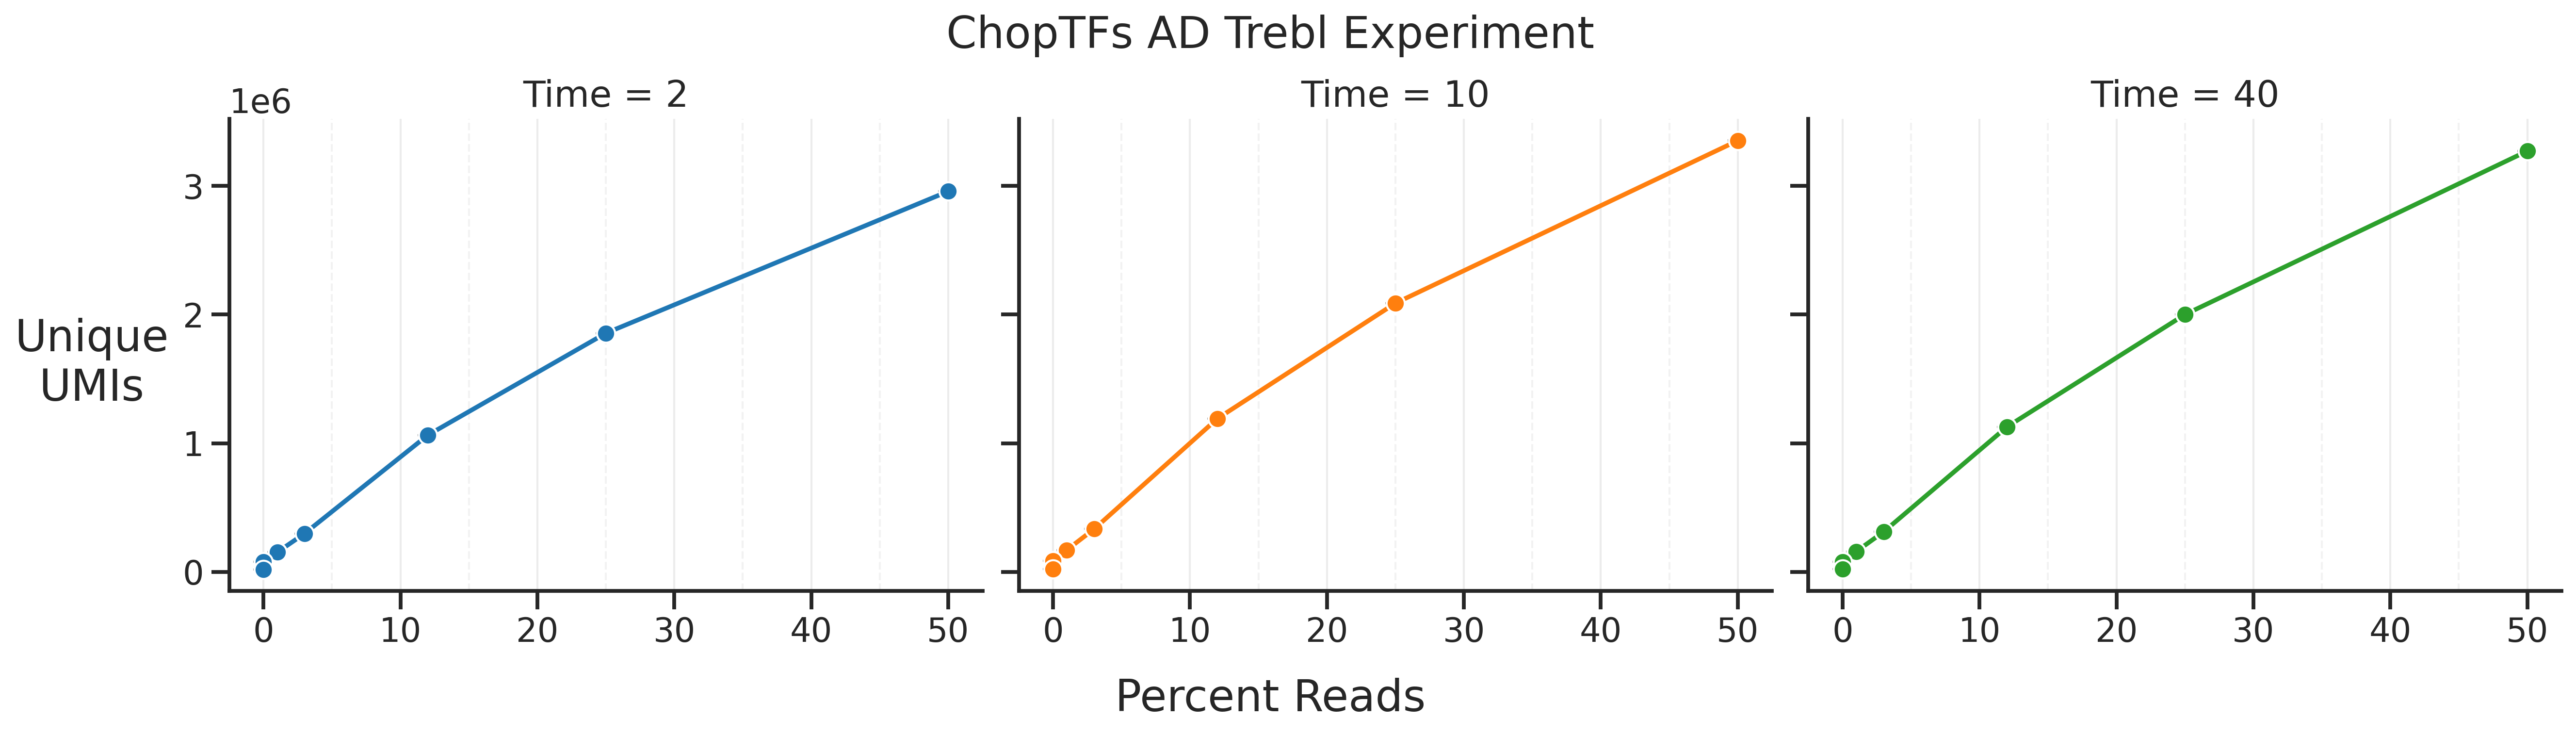

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns

sns.set_style("ticks")
sns.set_context("talk")

fig, axes = plt.subplots(
    1, 3, figsize=(18, 5), dpi=300, sharex=True, sharey=True
)

# Dictionary of summaries and colors
time_summaries = {
    'Time = 2': (time_2_summary, '#1f77b4'),   # blue
    'Time = 10': (time_10_summary, '#ff7f0e'), # orange
    'Time = 40': (time_40_summary, '#2ca02c'), # green
}

# Plot each time point
all_x = []
all_y = []

for ax, (title, (summary, color)) in zip(axes, time_summaries.items()):
    x = summary['percent_reads']
    y_mean = summary[('unique_umis', 'mean')]
    y_std = summary[('unique_umis', 'std')]
    
    all_x.append(x)
    all_y.append(y_mean)
    
    ax.errorbar(
        x=x,
        y=y_mean,
        yerr=y_std,
        fmt='-o',
        capsize=5,
        color=color,
        ecolor='tab:gray',
        elinewidth=2,
        markeredgecolor='white'
    )
    ax.set_title(title)
    ax.set_xlabel("")
    sns.despine(ax=ax)

# Shared limits and grids
all_x_concat = np.concatenate(all_x)
x_min, x_max = all_x_concat.min(), all_x_concat.max()
y_max = max(y.max() for y in all_y) * 1.05

for ax in axes:
    #ax.set_xlim(x_min - 1, x_max + 1)
    #ax.set_ylim(-1000, y_max)
    ax.grid(True, which='major', axis='x', linestyle='-', color='gray', alpha=0.15, linewidth=1)
    ax.xaxis.set_minor_locator(MultipleLocator(5))  # minor tick every 5%
    ax.grid(True, which='minor', axis='x', linestyle='--', color='gray', alpha=0.1, linewidth=1)
    ax.tick_params(axis='x', which='minor', length=0)

# Super labels and title
fig.supxlabel("Percent Reads")
fig.supylabel("Unique\nUMIs", rotation=0, ha='center', x=0.05)
fig.suptitle("ChopTFs AD Trebl Experiment")

plt.tight_layout(pad=0.5)
plt.show()

# RT activity correlation

In [50]:
step1_map = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/ChopTFs_pipeline/step1.csv")
step1_map = step1_map[["AD", "AD_end", "AD_BC", "RPTR_BC"]]
step1_map

,AD,AD_end,AD_BC,RPTR_BC
0,GTTGAGAAATTGCAATTCTTCTTGTTGTCTTATATTTCTGTTATGA...,AGGTGTTGATTTGATTAATGAATTGTGTCAAGGTTGTATT,CCAAATGACTA,GCTTGTACACATAC
1,TTGCCTAAATATTCTTCTTTGGATATTGATGATTTGTGTTCTGAAT...,GATTGTTGTTAAAGCTAGAGATTTGCAATCTGCTTTGGTT,ACTGAGCTAGA,CGCTGATGACCTAA
2,ACTAATATTAAACCATCTCCATCTTCTTCTGTTGATAATTTGAATG...,TGTTAATTCTTTGAATGATGAGTTCTGGACTGATTTGTTT,CTTCACAGGCC,TGCCCAGTGGACGC
3,TCTGCTCCAATGCCAATTAATCAAACTCAGAAGAAATTGTCTGATG...,GTCTAATTCTAATGATGTCTTGAATAATACTCCAAATTCT,TTCGACTCTCC,TAAATCTTGTAGTG
4,GATTCTAATCCAAATACTAATTTGGAAGATTCTTTGTTCTTTGATC...,TAATGGTCAAGGTTCTAATAATGGTAGACAAGCTTCTAAA,TAAACAGAGAC,CAGAAGTCTTTAAC
...,...,...,...,...
404383,AGAGAAACTTCTCAAACTGCTATGTTGACTGATCATGAAGATAATA...,TGCTGCTTCTTCTCCAAGATTGCCATTGTCTAGATTGAAT,CCCCGCTTTCT,TACCCTCGCGAAGC
404384,GTTGAAAGGATTCCAGATTCTGAATTGCAACATCATAAGAGAGTTG...,TATTCAAGAAGGTGAAGATATTAATCCAACTGAGTTCTTG,TCCCTTTACCG,GAGAGAAAAGGAGT
404385,AGAGTTACTGACTTTGGTGGTAAATCTTTGTCTATGGGATTCTCTT...,TTATGCTTTGAAAGGTTGGTATGATTCTAAAGGTAGAAAT,AATAATTCGTT,AAACTCTCCGCCTT
404386,GATTCTGAATTGCAACATCATAAGAGAGTTGAAGCTACTGAAGAAG...,AGATATTAATCCAACTGAGTTCTTGAAGAATTATAATGTT,AGAGCCTTGCA,CTTCGACTGTCTAG


In [107]:
def get_full_results(RT_umi_counts_tsv, AD_umi_counts_tsv):
    # Getting RT results alone
    RPTR_BC_umi_counts_t2 = pd.read_csv(RT_umi_counts_tsv, sep="\t")
    RPTR_BC_umi_counts_t2 = RPTR_BC_umi_counts_t2.rename(columns={"count": "RT_umi_count"})
    
    # Getting RT results alone
    AD_BC_umi_counts_t2 = pd.read_csv(AD_umi_counts_tsv, sep="\t")
    AD_BC_umi_counts_t2 = AD_BC_umi_counts_t2.rename(columns={"count": "AD_umi_count"})
    
    # Adding RT results to step 1 map
    step1_map_with_RPTR_BC_t2 = pd.merge(step1_map, RPTR_BC_umi_counts_t2)
    step1_map_with_RPTR_BC_AD_BC_t2 = pd.merge(step1_map_with_RPTR_BC_t2, AD_BC_umi_counts_t2)
    
    # Adding '_full' suffix to the last two columns
    step1_map_with_RPTR_BC_AD_BC_t2 = step1_map_with_RPTR_BC_AD_BC_t2.rename(
        columns={
            step1_map_with_RPTR_BC_AD_BC_t2.columns[-2]: step1_map_with_RPTR_BC_AD_BC_t2.columns[-2] + '_full',
            step1_map_with_RPTR_BC_AD_BC_t2.columns[-1]: step1_map_with_RPTR_BC_AD_BC_t2.columns[-1] + '_full'
        }
    )
    
    # Creating a copy and calculating activity
    step1_map_with_RPTR_BC_AD_BC_t2["activity_full"] = (
        step1_map_with_RPTR_BC_AD_BC_t2["RT_umi_count_full"].astype(int) /
        step1_map_with_RPTR_BC_AD_BC_t2["AD_umi_count_full"].astype(int)
    )
    
    return AD_BC_umi_counts_t2, RPTR_BC_umi_counts_t2, step1_map_with_RPTR_BC_AD_BC_t2

In [112]:
AD_BC_umi_counts_t2, RPTR_BC_umi_counts_t2, t2_full_activities = get_full_results("../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_RP_2_2_S32_R1_001_fastp/RP_2_2_S32_R1_001_fastp_simple_umi_counts.tsv",
                 "../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_AD_2_2_S2_R1_001_fastp/AD_2_2_S2_R1_001_fastp_simple_umi_counts.tsv")
display(AD_BC_umi_counts_t2)
t2_full_activities

,AD_end,AD_BC,AD_umi_count
0,TGTCTTCTTCATTTACTTTGGTTGCTAATAATCCACTCCA,GGCAAAACTCT,17188
1,TAATAATTCTAATTTGCAAACTTCTGGTATGGAGAATAAA,CAGTTTAGCTA,15042
2,TATGTCTGCTAATCATTATGTTGTTAATGATAATTCTACT,TGTCCTTGTCG,12399
3,TGGAGAATAAACAAACTGGTTTGGTCTTGGATTCTATGTT,GCCATATAGGT,11504
4,GTCTTCTTCATTTACTTTGGTTGCTAATAATCCAGCTCCA,CTCACCTGCCC,10522
...,...,...,...
319620,TTCCAATTTGTTCTCTTCTTTGGTTGGTGCTGATTGTTGT,TAAGGACGAGA,1
319621,TTTGAAAGCTGATCCTAATAAGAATAGAGATGCTAGAACT,GGAAAAATACG,1
319622,TGATTGTTGTTTTCATTCTGTTGATTTGAAATGTGGTGTT,TAGTCCGCATA,1
319623,TCCAGATCAGAATAGAGAATTGTGTTCTCCATGGGGTTTG,TCTTTGCAAAC,1


,AD,AD_end,AD_BC,RPTR_BC,RT_umi_count_full,AD_umi_count_full,activity_full
0,TTGAGATCTATTGGATTTAAACCAGAGAATTATACTAATTCTAATG...,TACTTTGGCTTCTAGATCTACTACTTCTAGATTGTTGCAA,AGACTATCAAT,GGAGGCTACCGCTC,5,15,0.333333
1,AATATTGCTAAACAATTGGCTGAGAAATTCTCTGTTTATGATCAAT...,TTCTGCTTCTCCACCACCAGCTCCTAAACATCATCATGCT,GCCCGTGGCAC,TTATGACCTATTCA,1,41,0.024390
2,GATTTGAATATTCATGTTAATACTAATAATATTGAAACTAAGAATG...,TCCATCTGATTATATTACTTATCCATCTCAAATTGCTACT,ATATGTAGCCC,TACGTTTGGCTATT,13,56,0.232143
3,TTGTTGTCTTATGCTGGTAATGCTGCTTCTTCTGAAACTTCTTCTC...,TCCAGATCATATTCATCATCATTCTAATAATATGAATAAT,TCTCTCTAGTA,GGATCCATGCCATA,8,53,0.150943
4,CCAAAAGTTCAACAAGCTGTTAGATTGAAATGGGGTTTGGATTGTA...,TTCTCAATCTTTGCAATCATTTAATCAAGTCTTGTTGTGT,GCCCCAAACTA,ACGAAGGTTGACCT,3,23,0.130435
...,...,...,...,...,...,...,...
42514,AGGAAAGATGCTTCTACTTCTACTATGAATAAATTGGTTTCTAATG...,AGGTGCTCCATTCTCTCCAGTTAATATTACTTTGCCAACT,AACGAAGAATG,TAAGATACAAGATC,11,62,0.177419
42515,GCTGAGAATAATGAAACTGCTCAATTGTTGCAACAAATTAATACTG...,GATTCAAACTTGTGAGAAATATATTCAAGTCTTGGAAGAA,GGCTTGTCAGA,AGATGGCGTATAAC,1,17,0.058824
42516,AGAAGACATGTTACATTCTCTAAGAGGAAACATGGTATTATGAAGA...,AGTCTTGTTGTTGGTTGTTTCTGAAACTGGTTTGGTTTAT,CCGGCGTACGG,CGAGACCTGGTACG,1,5,0.200000
42517,GATATCTTGCCACCTAAATCTGAATTGGTTGGTGGTGTTGAGAAAC...,ACATGAATGTCCATATTGTCATAGATTGTTCTCTCAAGCT,AATCGTCTCAG,GGGCCTAAGGTCCC,5,58,0.086207


In [113]:
AD_BC_umi_counts_t10, RPTR_BC_umi_counts_t10, t10_full_activities = get_full_results("../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_RP_2_10_S34_R1_001_fastp/RP_2_10_S34_R1_001_fastp_simple_umi_counts.tsv",
                 "../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_AD_2_10_S4_R1_001_fastp/AD_2_10_S4_R1_001_fastp_simple_umi_counts.tsv")
display(AD_BC_umi_counts_t10)
t10_full_activities

,AD_end,AD_BC,AD_umi_count
0,TGTCTTCTTCATTTACTTTGGTTGCTAATAATCCACTCCA,GGCAAAACTCT,20713
1,TAATAATTCTAATTTGCAAACTTCTGGTATGGAGAATAAA,CAGTTTAGCTA,18057
2,TATGTCTGCTAATCATTATGTTGTTAATGATAATTCTACT,TGTCCTTGTCG,15186
3,TGGAGAATAAACAAACTGGTTTGGTCTTGGATTCTATGTT,GCCATATAGGT,14207
4,GTCTTCTTCATTTACTTTGGTTGCTAATAATCCAGCTCCA,CTCACCTGCCC,13262
...,...,...,...
350728,TAAATCTCAACCAACTGAATCTCAGTTGATTTTGCAATCT,TGAAGGTTATC,1
350729,TAAGAAGAATAATGATGACTTTGATCATATTAGAGAGAAT,TGCATCTGGCG,1
350730,TTGAAATCTGAGAAATACTTTGTTAATGGGGAGGAGTAGT,TGTTTTATCGC,1
350731,TATTCCAACTGCTGCTGTTCCACAACAGAATATTGCTCCA,CAAGAACATGA,1


,AD,AD_end,AD_BC,RPTR_BC,RT_umi_count_full,AD_umi_count_full,activity_full
0,TTGAGATCTATTGGATTTAAACCAGAGAATTATACTAATTCTAATG...,TACTTTGGCTTCTAGATCTACTACTTCTAGATTGTTGCAA,AGACTATCAAT,GGAGGCTACCGCTC,1,17,0.058824
1,TCTCATGCTCCAACTGAACCAATTTCTAGAAGAGCTTCTTTGGTTG...,TTCTCAATCTGTTCATTATCATCCACAACATCAATATTAT,TTGGCTCTAGG,ATGTGTGCGTCCGC,3,20,0.150000
2,AATATTGCTAAACAATTGGCTGAGAAATTCTCTGTTTATGATCAAT...,TTCTGCTTCTCCACCACCAGCTCCTAAACATCATCATGCT,GCCCGTGGCAC,TTATGACCTATTCA,2,52,0.038462
3,GATTTGAATATTCATGTTAATACTAATAATATTGAAACTAAGAATG...,TCCATCTGATTATATTACTTATCCATCTCAAATTGCTACT,ATATGTAGCCC,TACGTTTGGCTATT,25,94,0.265957
4,TTGTTGTCTTATGCTGGTAATGCTGCTTCTTCTGAAACTTCTTCTC...,TCCAGATCATATTCATCATCATTCTAATAATATGAATAAT,TCTCTCTAGTA,GGATCCATGCCATA,12,58,0.206897
...,...,...,...,...,...,...,...
46174,AAAGTTAACTTTAGAAGGATTCCAACTGGTCCAGATTCTCCACCAA...,TGGTGTTCAAATGATCTTTATCTTGCCAGAACAAGAAACT,AACCCGCGACT,CTTCCGTTTGGTCC,1,1,1.000000
46175,CATTCTTCTGGTTCTTCTTTGGCTTTGGGTGAATTGTCTTCTAATT...,TGCTATGTCTGGTCCAGATTCTTTGTCTTCTTCTAAGAAT,AACAACCACGT,AGACAGCAGAGCGA,2,18,0.111111
46176,AGGAAAGATGCTTCTACTTCTACTATGAATAAATTGGTTTCTAATG...,AGGTGCTCCATTCTCTCCAGTTAATATTACTTTGCCAACT,AACGAAGAATG,TAAGATACAAGATC,4,47,0.085106
46177,GCTGAGAATAATGAAACTGCTCAATTGTTGCAACAAATTAATACTG...,GATTCAAACTTGTGAGAAATATATTCAAGTCTTGGAAGAA,GGCTTGTCAGA,AGATGGCGTATAAC,1,13,0.076923


In [114]:
AD_BC_umi_counts_t40, RPTR_BC_umi_counts_t40, t40_full_activities = get_full_results("../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_RP_2_40_S38_R1_001_fastp/RP_2_40_S38_R1_001_fastp_simple_umi_counts.tsv",
                 "../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_AD_2_40_S8_R1_001_fastp/AD_2_40_S8_R1_001_fastp_simple_umi_counts.tsv")
display(AD_BC_umi_counts_t40)
t40_full_activities

,AD_end,AD_BC,AD_umi_count
0,TGTCTTCTTCATTTACTTTGGTTGCTAATAATCCACTCCA,GGCAAAACTCT,20462
1,TAATAATTCTAATTTGCAAACTTCTGGTATGGAGAATAAA,CAGTTTAGCTA,17444
2,TATGTCTGCTAATCATTATGTTGTTAATGATAATTCTACT,TGTCCTTGTCG,15556
3,TGGAGAATAAACAAACTGGTTTGGTCTTGGATTCTATGTT,GCCATATAGGT,14128
4,GTCTTCTTCATTTACTTTGGTTGCTAATAATCCAGCTCCA,CTCACCTGCCC,12967
...,...,...,...
327337,CTTGGAAAGAAATTCTAATATGCATTCTAATAAGAAAGCT,ACCGACTAACT,1
327338,TAAAGTTTCTATCTTGGAGAGATTTATGGTTTCTGGTTCT,TTAATCCGGCG,1
327339,TAATGGTAATGTTAAAGAATTGGTTGAATGGAAATTCACT,ACTACCATCAG,1
327340,TCATTCTCATCCATTGGAAGATAATTTGTCCTTGGGTAAA,CACGGTACAAC,1


,AD,AD_end,AD_BC,RPTR_BC,RT_umi_count_full,AD_umi_count_full,activity_full
0,AATATTGCTAAACAATTGGCTGAGAAATTCTCTGTTTATGATCAAT...,TTCTGCTTCTCCACCACCAGCTCCTAAACATCATCATGCT,GCCCGTGGCAC,TTATGACCTATTCA,4,34,0.117647
1,GATTTGAATATTCATGTTAATACTAATAATATTGAAACTAAGAATG...,TCCATCTGATTATATTACTTATCCATCTCAAATTGCTACT,ATATGTAGCCC,TACGTTTGGCTATT,112,113,0.991150
2,TTGTTGTCTTATGCTGGTAATGCTGCTTCTTCTGAAACTTCTTCTC...,TCCAGATCATATTCATCATCATTCTAATAATATGAATAAT,TCTCTCTAGTA,GGATCCATGCCATA,14,59,0.237288
3,CCAAAAGTTCAACAAGCTGTTAGATTGAAATGGGGTTTGGATTGTA...,TTCTCAATCTTTGCAATCATTTAATCAAGTCTTGTTGTGT,GCCCCAAACTA,ACGAAGGTTGACCT,2,10,0.200000
4,CCAATTGTTCATTCTCCAACTTTGATGATGTTGTATAATAATCAAA...,GTTTAATTGTATCTTGGCTATTGGTGCTTGGTGTATTGAA,CTTAACGCCTA,TTGCAACCCCTTAC,4,31,0.129032
...,...,...,...,...,...,...,...
48326,AGGAAAGATGCTTCTACTTCTACTATGAATAAATTGGTTTCTAATG...,AGGTGCTCCATTCTCTCCAGTTAATATTACTTTGCCAACT,AACGAAGAATG,TAAGATACAAGATC,13,98,0.132653
48327,GCTGAGAATAATGAAACTGCTCAATTGTTGCAACAAATTAATACTG...,GATTCAAACTTGTGAGAAATATATTCAAGTCTTGGAAGAA,GGCTTGTCAGA,AGATGGCGTATAAC,3,20,0.150000
48328,GATATCTTGCCACCTAAATCTGAATTGGTTGGTGGTGTTGAGAAAC...,ACATGAATGTCCATATTGTCATAGATTGTTCTCTCAAGCT,AATCGTCTCAG,GGGCCTAAGGTCCC,15,52,0.288462
48329,AGAGAAACTTCTCAAACTGCTATGTTGACTGATCATGAAGATAATA...,TGCTGCTTCTTCTCCAAGATTGCCATTGTCTAGATTGAAT,CCCCGCTTTCT,TACCCTCGCGAAGC,1,23,0.043478


In [91]:
import os
import warnings
warnings.filterwarnings('ignore')
import tqdm
# Define the base directory
base_dir = "../../../output/ChopTFs_pipeline/downsampling/"

# Iterate through all folders in the base directory
for folder in tqdm.tqdm(os.listdir(base_dir)):
    folder_path = os.path.join(base_dir, folder)
    if os.path.isdir(folder_path) and "RP" in folder:
        # print(folder)
        # Process the RPTR_BC_umi_counts file
        umi_counts_path = next(
            (os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith("simple_umi_counts.tsv")),
            None
        )
        if umi_counts_path is None:
            continue
        RPTR_BC_umi_counts = pd.read_csv(umi_counts_path, sep="\t", encoding='latin-1')
        RPTR_BC_umi_counts = RPTR_BC_umi_counts.rename(columns={"count": "RT_umi_count"})

        # Merge with step1_map
        step1_map_with_RPTR_BC = pd.merge(step1_map, RPTR_BC_umi_counts, how="left")

        if "2_2" in folder:
            full_results = t2_full_activities
            AD_BC_counts = AD_BC_umi_counts_t2
        elif "2_10" in folder:
            full_results = t10_full_activities
            AD_BC_counts = AD_BC_umi_counts_t10
        elif "2_40" in folder:
            full_results = t40_full_activities
            AD_BC_counts = AD_BC_umi_counts_t40

        # Merge with AD_BC_counts
        step1_map_with_RPTR_BC_AD_BC = pd.merge(step1_map_with_RPTR_BC, AD_BC_counts, how="left")

        # Remove nulls
        step1_map_with_RPTR_BC_AD_BC_no_nulls = step1_map_with_RPTR_BC_AD_BC.dropna()

        step1_map_with_RPTR_BC_AD_BC_no_nulls = step1_map_with_RPTR_BC_AD_BC_no_nulls.rename(
            columns={step1_map_with_RPTR_BC_AD_BC_no_nulls.columns[-2]: step1_map_with_RPTR_BC_AD_BC_no_nulls.columns[-2] + '_downsampled',
                    step1_map_with_RPTR_BC_AD_BC_no_nulls.columns[-1]: step1_map_with_RPTR_BC_AD_BC_no_nulls.columns[-1] + '_downsampled'}
        )

        step1_map_with_RPTR_BC_AD_BC_no_nulls["activity_downsampled"] = step1_map_with_RPTR_BC_AD_BC_no_nulls["RT_umi_count_downsampled"].astype(int) / step1_map_with_RPTR_BC_AD_BC_no_nulls["AD_umi_count_downsampled"].astype(int)

        step1_map_with_RPTR_BC_AD_BC_no_nulls = pd.merge(
            full_results,
            step1_map_with_RPTR_BC_AD_BC_no_nulls,
            on=["AD", "AD_end", "RPTR_BC", "AD_BC"],
            how="inner",
        )

        # Save the processed file as a CSV
        output_path = os.path.join(folder_path, "processed_step1_map.csv")
        step1_map_with_RPTR_BC_AD_BC_no_nulls.to_csv(output_path, index=False)
        #print(f"Processed file saved to: {output_path}")

100%|██████████| 186/186 [01:29<00:00,  2.08it/s]


In [92]:
import pandas as pd
import os
from scipy.stats import pearsonr, spearmanr

# Initialize an empty list to store correlation results
correlation_results = []

# Loop through the base directory
for folder in tqdm.tqdm(os.listdir(base_dir)):
    folder_path = os.path.join(base_dir, folder)
    if os.path.isdir(folder_path) and "RP" in folder:
        processed_file_path = os.path.join(folder_path, "processed_step1_map.csv")
        if os.path.exists(processed_file_path):
            # Read the processed_step1_map.csv file
            df = pd.read_csv(processed_file_path)
            
            # Check if the required columns exist
            if "activity_full" in df.columns and "activity_downsampled" in df.columns:
                # Calculate Pearson and Spearman correlations
                pearson_corr, _ = pearsonr(df["activity_full"], df["activity_downsampled"])
                spearman_corr, _ = spearmanr(df["activity_full"], df["activity_downsampled"])
                
                # Append the results to the list
                correlation_results.append({
                    "folder_path": folder_path,
                    "pearson_corr": pearson_corr,
                    "spearman_corr": spearman_corr,
                    "num_rows": len(df)  # Track the number of rows
                })

                # Create scatterplot
                fig, ax = plt.subplots(figsize=(6,6), dpi=300)
                sns.set_context('talk')
                ax.scatter(df["activity_full"], df["activity_downsampled"], alpha=0.5, edgecolor = 'none', s = 5)
                ax.set_xscale('log')
                ax.set_yscale('log')
                ax.set_xlabel("Activity Full")
                ax.set_ylabel("Activity Downsampled")
                ax.set_title("Activity Full vs Activity Downsampled")
                ax.grid(False)
                sns.despine(ax=ax)

                # Add correlations as text
                ax.text(0.05, 0.95,
                        f"Pearson: {pearson_corr:.2f}\nSpearman: {spearman_corr:.2f}",
                        transform=ax.transAxes, fontsize=12, verticalalignment='top')

                # Save figure
                scatterplot_path = os.path.join(folder_path, "activity_scatterplot.png")
                plt.savefig(scatterplot_path, bbox_inches='tight')
                plt.close(fig)

# Convert the results into a DataFrame
correlation_df = pd.DataFrame(correlation_results)

# Display the correlation DataFrame
correlation_df

100%|██████████| 186/186 [01:34<00:00,  1.97it/s]


,folder_path,pearson_corr,spearman_corr,num_rows
0,../../../output/ChopTFs_pipeline/downsampling/...,0.748029,0.566789,18024
1,../../../output/ChopTFs_pipeline/downsampling/...,0.849062,0.709414,10654
2,../../../output/ChopTFs_pipeline/downsampling/...,0.982577,0.810607,28871
3,../../../output/ChopTFs_pipeline/downsampling/...,0.683980,0.598894,7135
4,../../../output/ChopTFs_pipeline/downsampling/...,0.981485,0.813641,28770
...,...,...,...,...
88,../../../output/ChopTFs_pipeline/downsampling/...,0.989279,0.977429,42135
89,../../../output/ChopTFs_pipeline/downsampling/...,0.964399,0.776570,21766
90,../../../output/ChopTFs_pipeline/downsampling/...,0.999207,0.977103,47071
91,../../../output/ChopTFs_pipeline/downsampling/...,0.737348,0.572695,18186


In [93]:
correlation_df['num_splits'] = correlation_df['folder_path'].str.extract(r'_(\d+)_chunks')#.astype(int)
correlation_df

,folder_path,pearson_corr,spearman_corr,num_rows,num_splits
0,../../../output/ChopTFs_pipeline/downsampling/...,0.748029,0.566789,18024,64
1,../../../output/ChopTFs_pipeline/downsampling/...,0.849062,0.709414,10654,512
2,../../../output/ChopTFs_pipeline/downsampling/...,0.982577,0.810607,28871,64
3,../../../output/ChopTFs_pipeline/downsampling/...,0.683980,0.598894,7135,512
4,../../../output/ChopTFs_pipeline/downsampling/...,0.981485,0.813641,28770,64
...,...,...,...,...,...
88,../../../output/ChopTFs_pipeline/downsampling/...,0.989279,0.977429,42135,2
89,../../../output/ChopTFs_pipeline/downsampling/...,0.964399,0.776570,21766,128
90,../../../output/ChopTFs_pipeline/downsampling/...,0.999207,0.977103,47071,4
91,../../../output/ChopTFs_pipeline/downsampling/...,0.737348,0.572695,18186,64


In [96]:
correlation_df["percent_reads"] = 100 / correlation_df["num_splits"].astype(float)
correlation_df

,folder_path,pearson_corr,spearman_corr,num_rows,num_splits,percent_reads
0,../../../output/ChopTFs_pipeline/downsampling/...,0.748029,0.566789,18024,64,1.562500
1,../../../output/ChopTFs_pipeline/downsampling/...,0.849062,0.709414,10654,512,0.195312
2,../../../output/ChopTFs_pipeline/downsampling/...,0.982577,0.810607,28871,64,1.562500
3,../../../output/ChopTFs_pipeline/downsampling/...,0.683980,0.598894,7135,512,0.195312
4,../../../output/ChopTFs_pipeline/downsampling/...,0.981485,0.813641,28770,64,1.562500
...,...,...,...,...,...,...
88,../../../output/ChopTFs_pipeline/downsampling/...,0.989279,0.977429,42135,2,50.000000
89,../../../output/ChopTFs_pipeline/downsampling/...,0.964399,0.776570,21766,128,0.781250
90,../../../output/ChopTFs_pipeline/downsampling/...,0.999207,0.977103,47071,4,25.000000
91,../../../output/ChopTFs_pipeline/downsampling/...,0.737348,0.572695,18186,64,1.562500


In [97]:
correlation_df["time"] = correlation_df["folder_path"].str.extract("RP_2_(\d+)_")
correlation_df

,folder_path,pearson_corr,spearman_corr,num_rows,num_splits,percent_reads,time
0,../../../output/ChopTFs_pipeline/downsampling/...,0.748029,0.566789,18024,64,1.562500,2
1,../../../output/ChopTFs_pipeline/downsampling/...,0.849062,0.709414,10654,512,0.195312,40
2,../../../output/ChopTFs_pipeline/downsampling/...,0.982577,0.810607,28871,64,1.562500,40
3,../../../output/ChopTFs_pipeline/downsampling/...,0.683980,0.598894,7135,512,0.195312,10
4,../../../output/ChopTFs_pipeline/downsampling/...,0.981485,0.813641,28770,64,1.562500,40
...,...,...,...,...,...,...,...
88,../../../output/ChopTFs_pipeline/downsampling/...,0.989279,0.977429,42135,2,50.000000,2
89,../../../output/ChopTFs_pipeline/downsampling/...,0.964399,0.776570,21766,128,0.781250,40
90,../../../output/ChopTFs_pipeline/downsampling/...,0.999207,0.977103,47071,4,25.000000,40
91,../../../output/ChopTFs_pipeline/downsampling/...,0.737348,0.572695,18186,64,1.562500,2


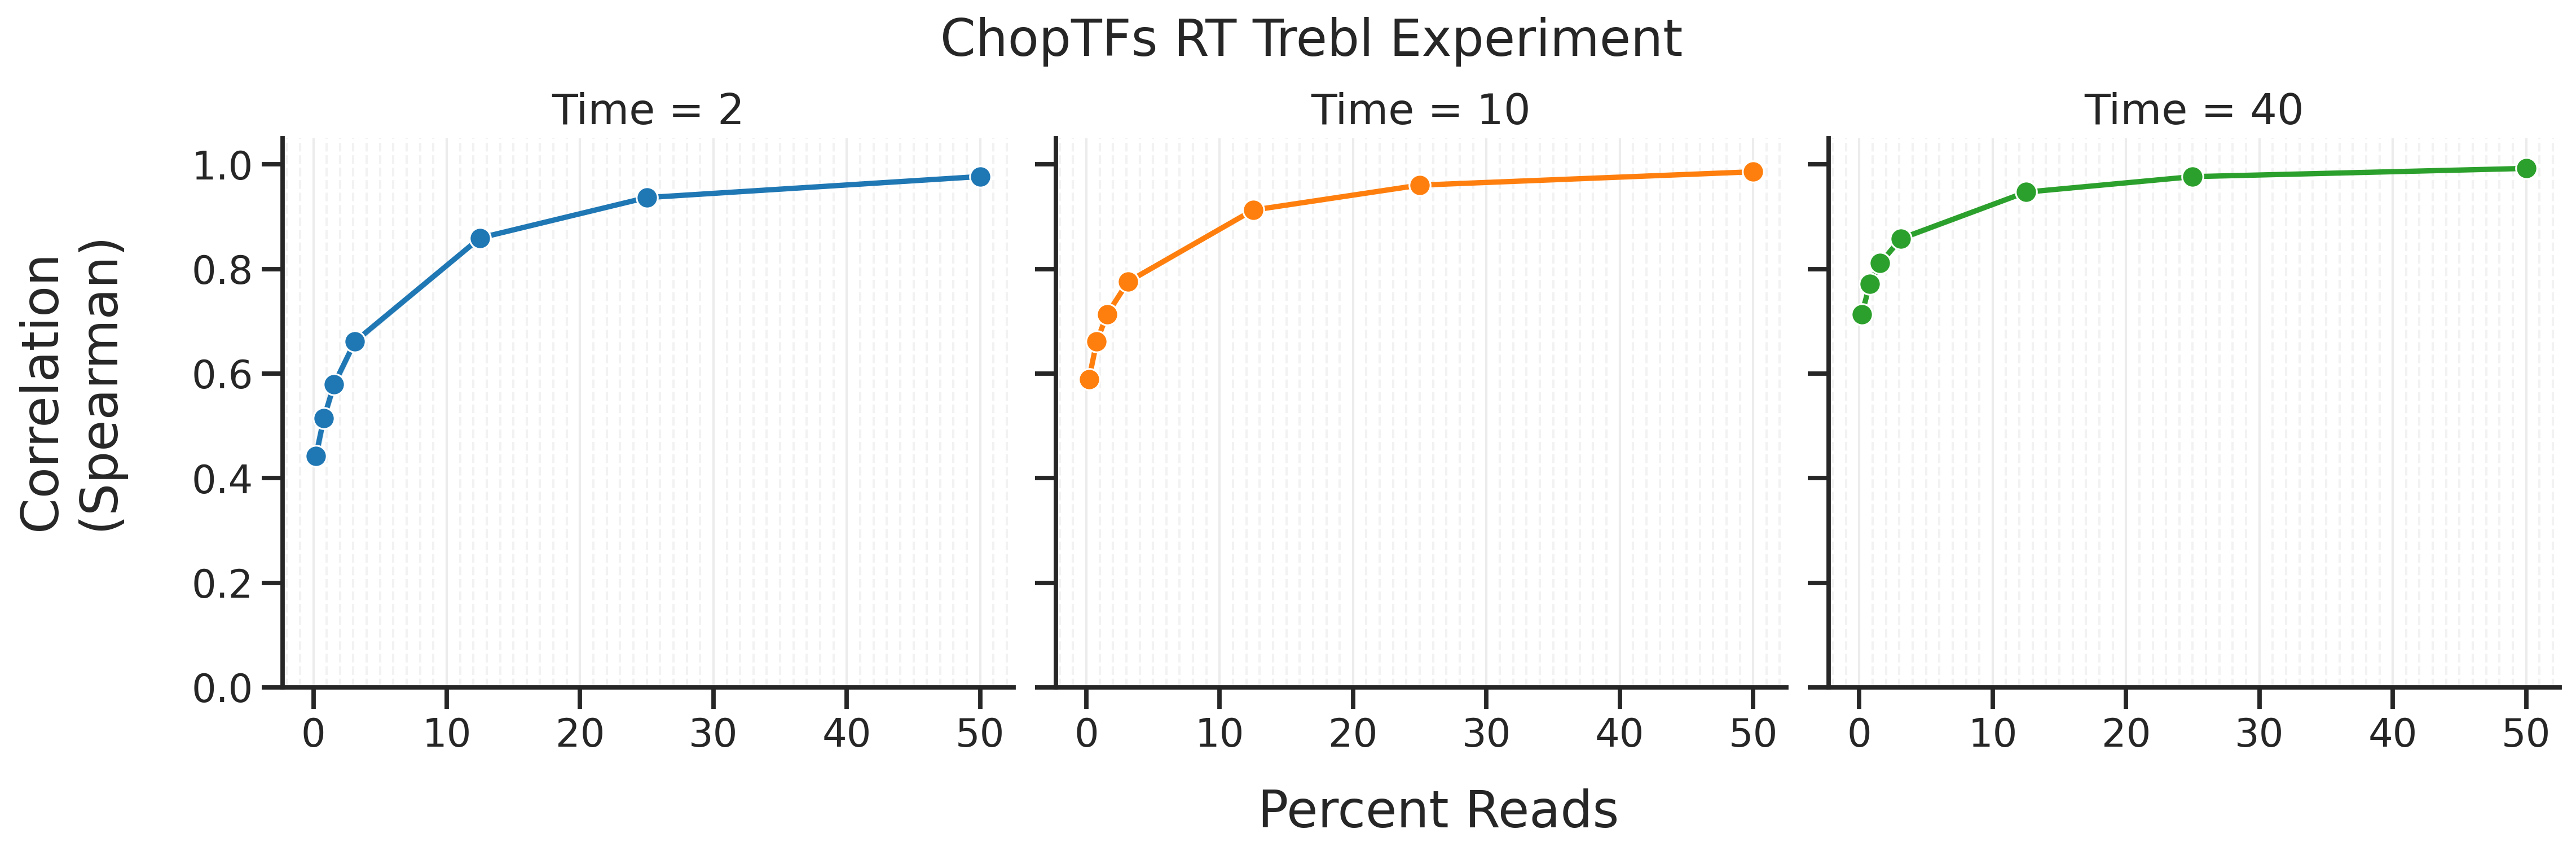

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Filter data for the specific time points
correlation_times = {
    "Time = 2": (correlation_df[correlation_df["time"] == "2"], "#1f77b4"),   # blue
    "Time = 10": (correlation_df[correlation_df["time"] == "10"], "#ff7f0e"), # orange
    "Time = 40": (correlation_df[correlation_df["time"] == "40"], "#2ca02c"), # green
}

sns.set_context("talk")
sns.set_style('ticks')

# Create 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=300, sharex=True, sharey=True)

for ax, (title, (df, color)) in zip(axes, correlation_times.items()):
    sns.lineplot(
        data=df,
        x="percent_reads",
        y="spearman_corr",
        estimator="median",
        errorbar=("sd"),
        marker="o",
        ax=ax,
        color=color
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine(ax=ax)

# Super labels and title
fig.supxlabel("Percent Reads", x=0.55)
fig.supylabel("Correlation\n(Spearman)", x=-0.01, y=0.55)
fig.suptitle("ChopTFs RT Trebl Experiment")

for ax in axes.flatten():
    # Major vertical grid lines
    ax.grid(True, which='major', axis='x', linestyle='-', color='gray', alpha=0.15, linewidth=1)
    # Minor ticks
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    # Minor vertical grid lines
    ax.grid(True, which='minor', axis='x', linestyle='--', color='gray', alpha=0.1, linewidth=1)
    ax.tick_params(axis='x', which='minor', length=0)
    # ax.set_xlim(-1, 21)
    ax.set_ylim(0,1.05)

plt.tight_layout(pad=0.5)
plt.show()

# AD correlation results

In [126]:
import os
import warnings
warnings.filterwarnings('ignore')
import tqdm
# Define the base directory
base_dir = "../../../output/ChopTFs_pipeline/downsampling/"

# Iterate through all folders in the base directory
for folder in tqdm.tqdm(os.listdir(base_dir)):
    folder_path = os.path.join(base_dir, folder)
    if os.path.isdir(folder_path) and "AD" in folder:
        # print(folder)
        # Process the RPTR_BC_umi_counts file
        umi_counts_path = next(
            (os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith("simple_umi_counts.tsv")),
            None
        )
        if umi_counts_path is None:
            continue
        AD_BC_umi_counts = pd.read_csv(umi_counts_path, sep="\t", encoding='latin-1')
        AD_BC_umi_counts = AD_BC_umi_counts.rename(columns={"count": "AD_umi_count"})
        
        # Merge with step1_map
        step1_map_with_AD_BC = pd.merge(step1_map, AD_BC_umi_counts, how="left")

        if "2_2" in folder:
            full_results = t2_full_activities
            RT_BC_counts = RPTR_BC_umi_counts_t2
        elif "2_10" in folder:
            full_results = t10_full_activities
            RT_BC_counts = RPTR_BC_umi_counts_t10
        elif "2_40" in folder:
            full_results = t40_full_activities
            RT_BC_counts = RPTR_BC_umi_counts_t40

        # Merge with AD_BC_counts
        step1_map_with_AD_BC_RT_BC = pd.merge(step1_map_with_AD_BC, RT_BC_counts, how="left")

        # Remove nulls
        step1_map_with_AD_BC_RT_BC_no_nulls = step1_map_with_AD_BC_RT_BC.dropna()

        step1_map_with_AD_BC_RT_BC_no_nulls = step1_map_with_AD_BC_RT_BC_no_nulls.rename(
            columns={
                "AD_umi_count": "AD_umi_count_downsampled",
                "RT_umi_count": "RT_umi_count_downsampled"
            }
        )

        # Calculate activity using downsampled AD and full RT
        step1_map_with_AD_BC_RT_BC_no_nulls["activity_downsampled"] = (
            step1_map_with_AD_BC_RT_BC_no_nulls["RT_umi_count_downsampled"].astype(int) /
            step1_map_with_AD_BC_RT_BC_no_nulls["AD_umi_count_downsampled"].astype(int)
        )
        
        step1_map_with_RPTR_BC_AD_BC_no_nulls = pd.merge(
            full_results,
            step1_map_with_AD_BC_RT_BC_no_nulls,
            on=["AD", "AD_end", "RPTR_BC", "AD_BC"],
            how="inner",
        )

        # Save the processed file as a CSV
        output_path = os.path.join(folder_path, "processed_step1_map.csv")
        step1_map_with_RPTR_BC_AD_BC_no_nulls.to_csv(output_path, index=False)
        #print(f"Processed file saved to: {output_path}")

100%|██████████| 186/186 [01:17<00:00,  2.39it/s]


In [128]:
import pandas as pd
import os
from scipy.stats import pearsonr, spearmanr

# Initialize an empty list to store correlation results
correlation_results = []

# Loop through the base directory
for folder in tqdm.tqdm(os.listdir(base_dir)):
    folder_path = os.path.join(base_dir, folder)
    if os.path.isdir(folder_path) and "AD" in folder:
        processed_file_path = os.path.join(folder_path, "processed_step1_map.csv")
        if os.path.exists(processed_file_path):
            # Read the processed_step1_map.csv file
            df = pd.read_csv(processed_file_path)
            
            # Check if the required columns exist
            if "activity_full" in df.columns and "activity_downsampled" in df.columns:
                # Calculate Pearson and Spearman correlations
                pearson_corr, _ = pearsonr(df["activity_full"], df["activity_downsampled"])
                spearman_corr, _ = spearmanr(df["activity_full"], df["activity_downsampled"])
                
                # Append the results to the list
                correlation_results.append({
                    "folder_path": folder_path,
                    "pearson_corr": pearson_corr,
                    "spearman_corr": spearman_corr,
                    "num_rows": len(df)  # Track the number of rows
                })

                # Create scatterplot
                fig, ax = plt.subplots(figsize=(6,6), dpi=300)
                sns.set_context('talk')
                ax.scatter(df["activity_full"], df["activity_downsampled"], alpha=0.5, edgecolor = 'none', s = 5)
                ax.set_xscale('log')
                ax.set_yscale('log')
                ax.set_xlabel("Activity Full")
                ax.set_ylabel("Activity Downsampled")
                ax.set_title("Activity Full vs Activity Downsampled")
                ax.grid(False)
                sns.despine(ax=ax)

                # Add correlations as text
                ax.text(0.05, 0.95,
                        f"Pearson: {pearson_corr:.2f}\nSpearman: {spearman_corr:.2f}",
                        transform=ax.transAxes, fontsize=12, verticalalignment='top')

                # Save figure
                scatterplot_path = os.path.join(folder_path, "activity_scatterplot.png")
                plt.savefig(scatterplot_path, bbox_inches='tight')
                plt.close(fig)

# Convert the results into a DataFrame
correlation_df = pd.DataFrame(correlation_results)

# Display the correlation DataFrame
correlation_df

100%|██████████| 186/186 [01:36<00:00,  1.92it/s]


,folder_path,pearson_corr,spearman_corr,num_rows
0,../../../output/ChopTFs_pipeline/downsampling/...,0.643533,0.783673,18907
1,../../../output/ChopTFs_pipeline/downsampling/...,0.870448,0.927251,44895
2,../../../output/ChopTFs_pipeline/downsampling/...,0.751687,0.674830,19706
3,../../../output/ChopTFs_pipeline/downsampling/...,0.879872,0.950876,45176
4,../../../output/ChopTFs_pipeline/downsampling/...,0.694899,0.820941,27077
...,...,...,...,...
87,../../../output/ChopTFs_pipeline/downsampling/...,0.813074,0.786390,34821
88,../../../output/ChopTFs_pipeline/downsampling/...,0.821217,0.901668,43580
89,../../../output/ChopTFs_pipeline/downsampling/...,0.944122,0.985118,47888
90,../../../output/ChopTFs_pipeline/downsampling/...,0.884756,0.949890,45100


In [129]:
correlation_df['num_splits'] = correlation_df['folder_path'].str.extract(r'_(\d+)_chunks')#.astype(int)
correlation_df

,folder_path,pearson_corr,spearman_corr,num_rows,num_splits
0,../../../output/ChopTFs_pipeline/downsampling/...,0.643533,0.783673,18907,128
1,../../../output/ChopTFs_pipeline/downsampling/...,0.870448,0.927251,44895,8
2,../../../output/ChopTFs_pipeline/downsampling/...,0.751687,0.674830,19706,128
3,../../../output/ChopTFs_pipeline/downsampling/...,0.879872,0.950876,45176,4
4,../../../output/ChopTFs_pipeline/downsampling/...,0.694899,0.820941,27077,64
...,...,...,...,...,...
87,../../../output/ChopTFs_pipeline/downsampling/...,0.813074,0.786390,34821,32
88,../../../output/ChopTFs_pipeline/downsampling/...,0.821217,0.901668,43580,8
89,../../../output/ChopTFs_pipeline/downsampling/...,0.944122,0.985118,47888,2
90,../../../output/ChopTFs_pipeline/downsampling/...,0.884756,0.949890,45100,4


In [130]:
correlation_df["percent_reads"] = 100 / correlation_df["num_splits"].astype(float)
correlation_df

,folder_path,pearson_corr,spearman_corr,num_rows,num_splits,percent_reads
0,../../../output/ChopTFs_pipeline/downsampling/...,0.643533,0.783673,18907,128,0.78125
1,../../../output/ChopTFs_pipeline/downsampling/...,0.870448,0.927251,44895,8,12.50000
2,../../../output/ChopTFs_pipeline/downsampling/...,0.751687,0.674830,19706,128,0.78125
3,../../../output/ChopTFs_pipeline/downsampling/...,0.879872,0.950876,45176,4,25.00000
4,../../../output/ChopTFs_pipeline/downsampling/...,0.694899,0.820941,27077,64,1.56250
...,...,...,...,...,...,...
87,../../../output/ChopTFs_pipeline/downsampling/...,0.813074,0.786390,34821,32,3.12500
88,../../../output/ChopTFs_pipeline/downsampling/...,0.821217,0.901668,43580,8,12.50000
89,../../../output/ChopTFs_pipeline/downsampling/...,0.944122,0.985118,47888,2,50.00000
90,../../../output/ChopTFs_pipeline/downsampling/...,0.884756,0.949890,45100,4,25.00000


In [133]:
correlation_df["time"] = correlation_df["folder_path"].str.extract("AD_2_(\d+)_")
correlation_df

,folder_path,pearson_corr,spearman_corr,num_rows,num_splits,percent_reads,time
0,../../../output/ChopTFs_pipeline/downsampling/...,0.643533,0.783673,18907,128,0.78125,40
1,../../../output/ChopTFs_pipeline/downsampling/...,0.870448,0.927251,44895,8,12.50000,40
2,../../../output/ChopTFs_pipeline/downsampling/...,0.751687,0.674830,19706,128,0.78125,10
3,../../../output/ChopTFs_pipeline/downsampling/...,0.879872,0.950876,45176,4,25.00000,10
4,../../../output/ChopTFs_pipeline/downsampling/...,0.694899,0.820941,27077,64,1.56250,40
...,...,...,...,...,...,...,...
87,../../../output/ChopTFs_pipeline/downsampling/...,0.813074,0.786390,34821,32,3.12500,10
88,../../../output/ChopTFs_pipeline/downsampling/...,0.821217,0.901668,43580,8,12.50000,10
89,../../../output/ChopTFs_pipeline/downsampling/...,0.944122,0.985118,47888,2,50.00000,40
90,../../../output/ChopTFs_pipeline/downsampling/...,0.884756,0.949890,45100,4,25.00000,10


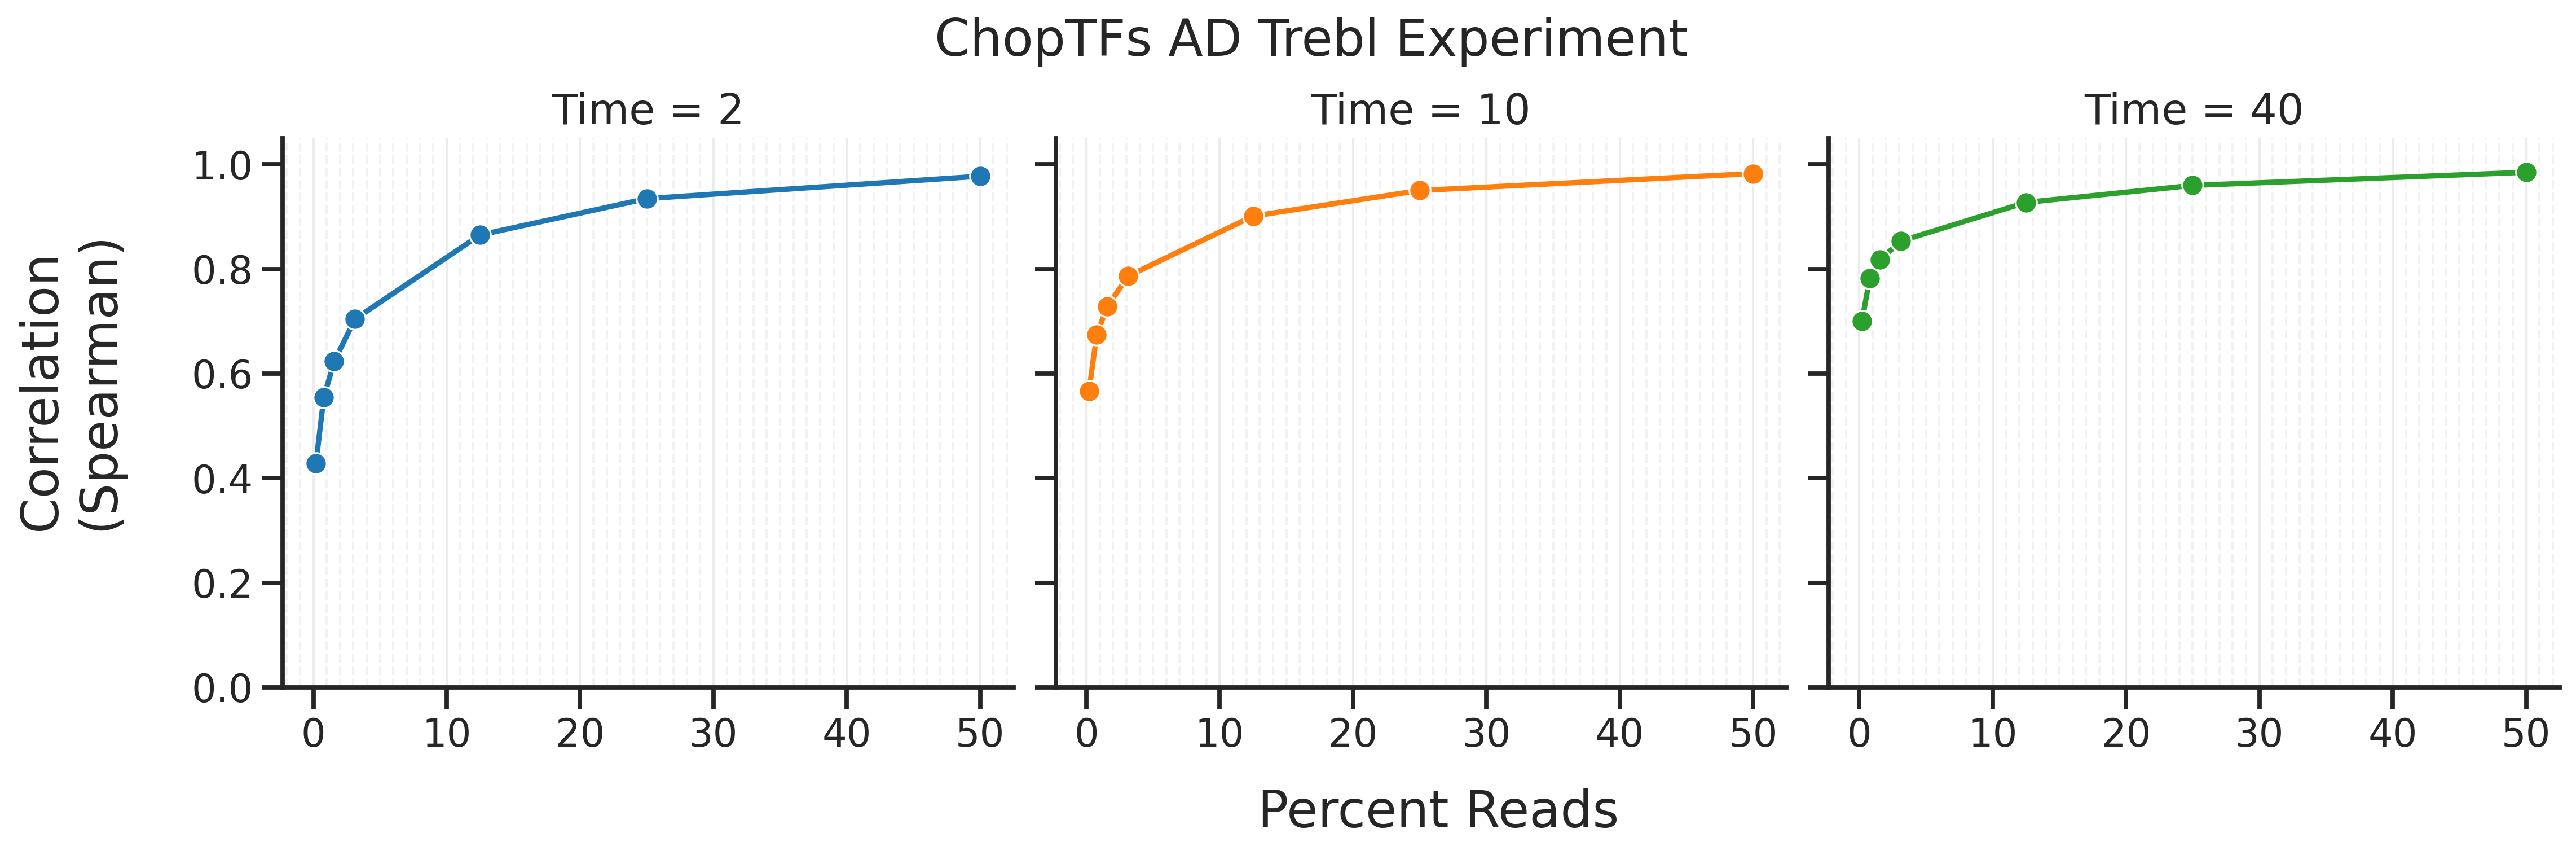

In [134]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Filter data for the specific time points
correlation_times = {
    "Time = 2": (correlation_df[correlation_df["time"] == "2"], "#1f77b4"),   # blue
    "Time = 10": (correlation_df[correlation_df["time"] == "10"], "#ff7f0e"), # orange
    "Time = 40": (correlation_df[correlation_df["time"] == "40"], "#2ca02c"), # green
}

sns.set_context("talk")
sns.set_style('ticks')

# Create 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=300, sharex=True, sharey=True)

for ax, (title, (df, color)) in zip(axes, correlation_times.items()):
    sns.lineplot(
        data=df,
        x="percent_reads",
        y="spearman_corr",
        estimator="median",
        errorbar=("sd"),
        marker="o",
        ax=ax,
        color=color
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine(ax=ax)

# Super labels and title
fig.supxlabel("Percent Reads", x=0.55)
fig.supylabel("Correlation\n(Spearman)", x=-0.01, y=0.55)
fig.suptitle("ChopTFs AD Trebl Experiment")

for ax in axes.flatten():
    # Major vertical grid lines
    ax.grid(True, which='major', axis='x', linestyle='-', color='gray', alpha=0.15, linewidth=1)
    # Minor ticks
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    # Minor vertical grid lines
    ax.grid(True, which='minor', axis='x', linestyle='--', color='gray', alpha=0.1, linewidth=1)
    ax.tick_params(axis='x', which='minor', length=0)
    # ax.set_xlim(-1, 21)
    ax.set_ylim(0,1.05)

plt.tight_layout(pad=0.5)
plt.show()